In [321]:
from pathlib import Path
from pprint import pprint
from statistics import mean
from dataclasses import dataclass
import json
from datetime import datetime
from typing import Optional
from plot_utilities import Color, line_plot, double_sided_bar_plot, plot_model_agent_heatmap, plot_model_series, plot_stacked_histograms, color_check_plot, plot_stacked_bar_from_nested_dict, plot_error_code_bars, plot_stacked_bar_with_line, line_plot_with_box_plots, plot_count_bars
from data_utilities import TBRun, Trial, split_trail_list, parse_trial
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


In [322]:
FINAL_RUNS_DIR_PATH = Path().resolve().parent / 'final_runs'
FINAL_RUNS_IDS = [d.name for d in FINAL_RUNS_DIR_PATH.iterdir() if d.is_dir()]

In [323]:
# each benchmark run is transferred to an instance of TBRun
tb_runs: list[TBRun] = []
for run_id in FINAL_RUNS_IDS:
    print(f"-> parsing {run_id}")

    # read in main logs
    with (FINAL_RUNS_DIR_PATH / run_id / 'config.json').open("r") as f:
        config = json.load(f)
    with (FINAL_RUNS_DIR_PATH / run_id / 'result.json').open("r") as f:
        result = json.load(f)
        
    # parse data
    model = run_id.split('_')[1]
    agent = run_id.split('_')[0]
    started_at = datetime.fromisoformat(result.get("started_at"))
    finished_at = datetime.fromisoformat(result.get("finished_at"))
    n_attempts = config.get("n_attempts")
    n_total_trials = result.get("n_total_trials")

    # parse trials
    trials = dict()
    for d in (FINAL_RUNS_DIR_PATH / run_id).iterdir():
        if not d.is_dir():
            continue
        trials[d.name] = parse_trial(d, agent, model)
    assert len(trials) == n_total_trials
    
    # parse n_attempts
    stats_eval = result['stats']['evals'][list(result['stats']['evals'].keys())[0]] 
    trial_rewards_ids = stats_eval['reward_stats']['reward']['1.0']
    trial_no_rewards_ids = stats_eval['reward_stats']['reward']['0.0']
    stats_eval_mean = stats_eval['metrics'][0]['mean']
    assert len(trial_rewards_ids) + len(trial_no_rewards_ids) == stats_eval['n_trials']
    # split trial lists if more than one attempts
    if n_attempts > 1:
        trial_rewards_ids = split_trail_list(trial_rewards_ids)
        trial_no_rewards_ids = split_trail_list(trial_no_rewards_ids)
    else:
        trial_rewards_ids = [trial_rewards_ids]
        trial_no_rewards_ids = [trial_no_rewards_ids]
    assert sum(len(ts) for ts in trial_rewards_ids) / n_total_trials == stats_eval_mean
    
    # create final TBRun objects
    for n in range(1, n_attempts + 1):
        
        # calc mean
        solved_tasks = trial_rewards_ids[n - 1]
        unsolved_tasks = trial_no_rewards_ids[n - 1]
        mean_n = len(solved_tasks) / (n_total_trials / n_attempts)
        mean_n_rel = sum(trials[t].verifier_tests_passed_relative or 0 for t in solved_tasks + unsolved_tasks) / (n_total_trials / n_attempts)
        print(f"trial {n} mean: {mean_n:.4f} ({mean_n_rel:.4f} - n: {len(solved_tasks + unsolved_tasks)})")
        
        # collect all related trial objects
        trials_n = {t: trials[t] for t in solved_tasks + unsolved_tasks}
        total_prompt_tokens = sum(t.total_prompt_tokens or 0 for t in trials_n.values())
        total_completion_tokens = sum(t.total_completion_tokens or 0 for t in trials_n.values())
    
        # craft final RBTun data object
        tb_runs.append(TBRun(
            run_id=run_id,
            model=model,
            agent=agent,
            started_at=started_at,
            finished_at=finished_at,
            n_total_trials=n_total_trials,
            n_attempts=n_attempts,
            i_of_n_attempts=n,
            n_errors=stats_eval.get("n_errors"),
            accuracy_mean=mean_n,
            accuracy_mean_rel=mean_n_rel,
            solved_tasks=solved_tasks,
            unsolved_tasks=unsolved_tasks,
            exception_stats=stats_eval.get("exception_stats"),
            trials=trials_n,
            total_prompt_tokens=total_prompt_tokens,
            total_completion_tokens=total_completion_tokens
        ))

-> parsing singleton_gpt-5-mini_2025-11-26__18-36-33
trial 1 mean: 0.2921 (0.5299 - n: 89)
-> parsing spoox-l_gpt-5-nano_2025-12-01__08-24-53
trial 1 mean: 0.1573 (0.3927 - n: 88)
-> parsing spoox-m_gpt-5-mini_2025-11-29__09-10-37
trial 1 mean: 0.4045 (0.5767 - n: 88)
trial 2 mean: 0.3483 (0.5466 - n: 88)
trial 3 mean: 0.3371 (0.5420 - n: 88)
trial 4 mean: 0.2921 (0.5085 - n: 88)
trial 5 mean: 0.3596 (0.5398 - n: 89)
-> parsing spoox-m_gpt-5-nano_2025-12-04__09-36-32
trial 1 mean: 0.0899 (0.3183 - n: 88)
-> parsing singleton_gpt-5-mini_2025-11-28__10-23-29
trial 1 mean: 0.2921 (0.5089 - n: 85)
-> parsing spoox-l_gpt-5-mini_2025-11-27__18-39-31
trial 1 mean: 0.3034 (0.5036 - n: 88)
-> parsing spoox-s_gpt-5-mini_2025-12-01__16-47-43
trial 1 mean: 0.3596 (0.5715 - n: 88)
-> parsing spoox-l_gpt-5-nano_2025-12-02__22-37-05
trial 1 mean: 0.0674 (0.1885 - n: 52)
-> parsing spoox-s_gpt-5-mini_2025-12-01__23-52-09
trial 1 mean: 0.3258 (0.5148 - n: 88)
-> parsing spoox-s_gpt-5-mini_2025-11-27__1

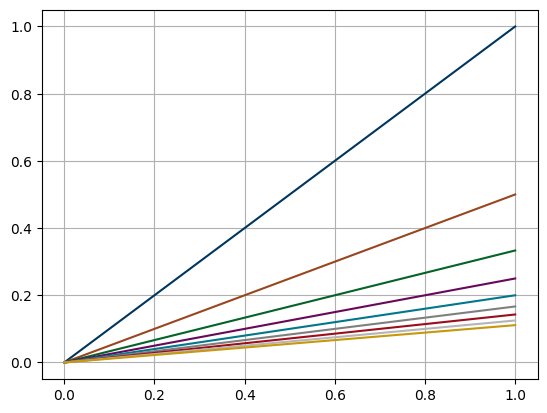

In [324]:
# color checks
color_check_plot()

# Performance

In [325]:
# agents and models
x_labels_agents = ['singleton', 'spoox-s', 'spoox-m', 'spoox-l']
models = ['gpt-5-mini', 'gpt-5-nano']

# list of all task ids
task_names = set() 
for r in tb_runs:
    for t in r.trials.values():
        task_names.add(t.task_name)
assert(len(task_names) == 89)

# agent runs count
agent_runs = {m: {a: sum(1 for r in tb_runs if r.agent == a and r.model == m) for a in x_labels_agents} for m in models}
pprint(agent_runs)

{'gpt-5-mini': {'singleton': 3, 'spoox-l': 3, 'spoox-m': 5, 'spoox-s': 3},
 'gpt-5-nano': {'singleton': 3, 'spoox-l': 3, 'spoox-m': 3, 'spoox-s': 3}}


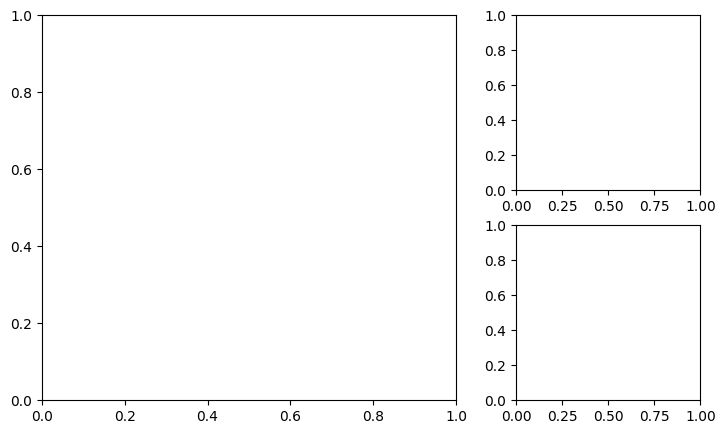

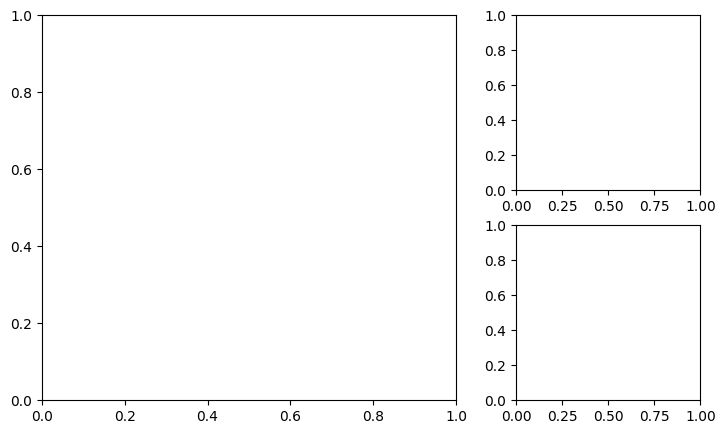

In [326]:
# plots to collect accuracy plots
# accuracy
fig_accs = plt.figure(figsize=(8.5, 5))
gs_accs = GridSpec(2, 2, figure=fig_accs, width_ratios=[9, 4])  # Define a 2×2 grid
ax_left_accs = fig_accs.add_subplot(gs_accs[:, 0])  # Left column: Plot 1 spans both rows
ax_top_right_accs = fig_accs.add_subplot(gs_accs[0, 1])  # Right column: Plot 2 (top), Plot 3 (bottom)
ax_bottom_right_accs = fig_accs.add_subplot(gs_accs[1, 1])
# weighted accuracy
fig_accs_w = plt.figure(figsize=(8.5, 5))
gs_accs_w = GridSpec(2, 2, figure=fig_accs_w, width_ratios=[9, 4])  # Define a 2×2 grid
ax_left_accs_w = fig_accs_w.add_subplot(gs_accs_w[:, 0])  # Left column: Plot 1 spans both rows
ax_top_right_accs_w = fig_accs_w.add_subplot(gs_accs_w[0, 1])  # Right column: Plot 2 (top), Plot 3 (bottom)
ax_bottom_right_accs_w = fig_accs_w.add_subplot(gs_accs_w[1, 1])

In [327]:
# -- accuracy line plot --
# gather data
y_values_acc = {m: [[] for _ in x_labels_agents] for m in models}
y_horizontal_lines = [
    ('Codex CLI – gpt-5-mini', 0.319, Color.LIGHT_BLUE),
    ('Codex CLI – gpt-5-nano', 0.115, Color.LIGHT_ORANGE),
]
for m in models:
    for i, x in enumerate(x_labels_agents):
        for r in tb_runs:
            if r.model == m and r.agent == x:
                y_values_acc[m][i].append(r.accuracy_mean)
                
print(y_values_acc)
line_plot(
    ax_left_accs, x_labels_agents, y_values_acc, 
    y_1_horizontal_lines=y_horizontal_lines, y_1_label='accuracy', y_1_lim=(0, 0.45), y_1_tic_steps=0.05
)

{'gpt-5-mini': [[0.29213483146067415, 0.29213483146067415, 0.30337078651685395], [0.3595505617977528, 0.3258426966292135, 0.33707865168539325], [0.4044943820224719, 0.34831460674157305, 0.33707865168539325, 0.29213483146067415, 0.3595505617977528], [0.30337078651685395, 0.30337078651685395, 0.33707865168539325]], 'gpt-5-nano': [[0.07865168539325842, 0.11235955056179775, 0.10112359550561797], [0.10112359550561797, 0.0898876404494382, 0.07865168539325842], [0.0898876404494382, 0.12359550561797752, 0.10112359550561797], [0.15730337078651685, 0.06741573033707865, 0.0898876404494382]]}


In [328]:
for vs in y_values_acc['gpt-5-nano']:
    print(mean(vs))

0.09737827715355805
0.0898876404494382
0.1048689138576779
0.1048689138576779


In [329]:
vs = [0.3464200593414076, 0.3329908231593625, 0.33475890526452323]
print(mean(vs))
print(np.std(vs, ddof=1))

0.33805659592176446
0.007296723159160518


In [330]:
# -- test-accuracy line plot --
# gather data
models = ['gpt-5-mini', 'gpt-5-nano']
x_labels_agents = ['singleton', 'spoox-s', 'spoox-m', 'spoox-l']
y_values_acc_rel = {m: [[] for _ in x_labels_agents] for m in models}
for m in models:
    for i, x in enumerate(x_labels_agents):
        for r in tb_runs:
            if r.model == m and r.agent == x:
                y_values_acc_rel[m][i].append(r.accuracy_mean_rel)
# plot
print(y_values_acc_rel)
line_plot(
    ax_left_accs_w, x_labels_agents, y_values_acc_rel, 
    y_1_label='weighted accuracy', y_1_lim=(0, 0.65), y_1_tic_steps=0.1
)

{'gpt-5-mini': [[0.5298563483956742, 0.5088825656241387, 0.5041474131361772], [0.5715015321756896, 0.5148013035653485, 0.5032645880960488], [0.5766898519707508, 0.5465505780112522, 0.5420002594159898, 0.508495062989445, 0.5397814420286331], [0.5036091249574396, 0.5225700017834849, 0.5283225513562592]], 'gpt-5-nano': [[0.24582502391491154, 0.3562742189146683, 0.38183601666747735], [0.3464200593414076, 0.3329908231593625, 0.33475890526452323], [0.31829977138965904, 0.37166772054412506, 0.362723948959904], [0.3927464857240138, 0.18849652220438737, 0.3795997697683091]]}


In [331]:
# calc list of mean accuracy for each model and agent combination
acc_means = {model: [mean(a_accs) if a_accs else None for a_accs in agent_accs] for model, agent_accs in y_values_acc.items()}
acc_means
# -- accuracy development plot --
# gather data
x_labels_models = ['SGL ▸ S', 'S ▸ M', 'M ▸ L']
y_values_accs_steps = dict()
for m in models:
    agent_accs = acc_means[m]
    steps = []
    for i in range(len(x_labels_agents) - 1):
        if agent_accs[i] is None or agent_accs[i + 1] is None:
            steps.append(None)
        else:
            steps.append((agent_accs[i + 1] - agent_accs[i]) / agent_accs[i])
    y_values_accs_steps[m] = steps

# plot
print(y_values_accs_steps)
m = 'gpt-5-mini'
double_sided_bar_plot(
    ax_top_right_accs,
    x_labels_models, 
    "scaling steps",
    {m: y_values_accs_steps[m]},
    y_title="rel acc gain", 
    y_tic_steps=0.1,
    y_lim=(-0.18, 0.18),
    legend=False,
    bar_colors=[Color.DARK_BLUE],
)
m = 'gpt-5-nano'
double_sided_bar_plot(
    ax_bottom_right_accs,
    x_labels_models, 
    "scaling steps",
    {m: y_values_accs_steps[m]},
    y_title="rel acc gain",
    y_tic_steps=0.1,
    y_lim=(-0.18, 0.18),
    legend=False,
    bar_colors=[Color.ORANGE],
)

{'gpt-5-mini': [0.1518987341772152, 0.021978021978022032, -0.09677419354838716], 'gpt-5-nano': [-0.07692307692307697, 0.1666666666666666, 0.0]}


In [332]:
# calc list of mean accuracy for each model and agent combination
acc_means_rel = {model: [mean(a_accs) if a_accs else None for a_accs in agent_accs] for model, agent_accs in y_values_acc_rel.items()}
acc_means

{'gpt-5-mini': [0.2958801498127341,
  0.3408239700374532,
  0.34831460674157305,
  0.3146067415730337],
 'gpt-5-nano': [0.09737827715355805,
  0.0898876404494382,
  0.1048689138576779,
  0.1048689138576779]}

In [333]:
# -- accuracy development plot --
# gather data
x_labels_models = ['SGL ▸ S', 'S ▸ M', 'M ▸ L']
y_values_accs_rel_steps = dict()
for m in models:
    agent_accs = acc_means_rel[m]
    steps = []
    for i in range(len(x_labels_agents) - 1):
        if agent_accs[i] is None or agent_accs[i + 1] is None:
            steps.append(None)
        else:
            steps.append((agent_accs[i + 1] - agent_accs[i]) / agent_accs[i])
    y_values_accs_rel_steps[m] = steps

# plot
print(y_values_accs_rel_steps)
m = 'gpt-5-mini'
double_sided_bar_plot(
    ax_top_right_accs_w,
    x_labels_models, 
    "scaling steps",
    {m: y_values_accs_rel_steps[m]},
    y_title="rel w-acc gain",
    y_tic_steps=0.05,
    y_lim=(-0.09, 0.09),
    legend=False,
    bar_colors=[Color.DARK_BLUE],
)
m = 'gpt-5-nano'
double_sided_bar_plot(
    ax_bottom_right_accs_w,
    x_labels_models, 
    "scaling steps",
    {m: y_values_accs_rel_steps[m]},
    y_title="rel w-acc gain",
    y_tic_steps=0.05,
    y_lim=(-0.09, 0.09),
    legend=False,
    bar_colors=[Color.ORANGE],
)

{'gpt-5-mini': [0.030255694058255404, 0.02424740985161617, -0.045211087848108615], 'gpt-5-nano': [0.030728168318401954, 0.03798343590305186, -0.08725126815793462]}


In [334]:
# save the accuracy plots
fig_accs.tight_layout()
fig_accs.savefig("figure_accs.pdf")
fig_accs_w.tight_layout()
fig_accs_w.savefig("figure_accs-w.pdf")

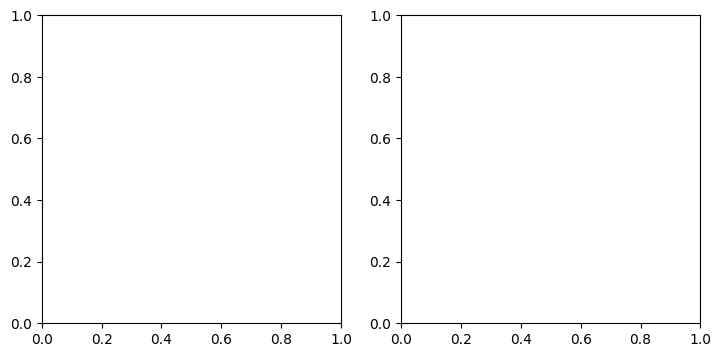

In [335]:
# new plot grids for next plots
# task solved stats
fig_accs_c = plt.figure(figsize=(8.5, 4))
gs_accs_c = GridSpec(1, 2, figure=fig_accs_c, width_ratios=[1,1])
ax_left_accs_c = fig_accs_c.add_subplot(gs_accs_c[0, 0])
ax_right_accs_c = fig_accs_c.add_subplot(gs_accs_c[0, 1]) 

In [336]:
# map task to agent solved
agent_tasked_sovled_count_gpt_mini = {a: {t: 0 for t in task_names} for a in x_labels_agents}
agent_tasked_sovled_count_gpt_nano = {a: {t: 0 for t in task_names} for a in x_labels_agents}
for r in tb_runs:
    for t in r.trials.values():
        solved_value = 1 if t.trial_id in r.solved_tasks else 0
        if r.model == 'gpt-5-mini':
            agent_tasked_sovled_count_gpt_mini[r.agent][t.task_name] += solved_value
        elif r.model == 'gpt-5-nano':
            agent_tasked_sovled_count_gpt_nano[r.agent][t.task_name] += solved_value
            
agent_solved_distri_gpt_mini = {a: {i: 0 for i in range(agent_runs['gpt-5-mini'][a] + 1)} for a in x_labels_agents}
agent_solved_distri_gpt_nano = {a: {i: 0 for i in range(agent_runs['gpt-5-nano'][a] + 1)} for a in x_labels_agents}

for a, t_dict in agent_tasked_sovled_count_gpt_mini.items():
    for t, t_solved_count in t_dict.items():
        agent_solved_distri_gpt_mini[a][t_solved_count] += 1
pprint(agent_solved_distri_gpt_mini)
for a, t_dict in agent_tasked_sovled_count_gpt_nano.items():
    for t, t_solved_count in t_dict.items():
        agent_solved_distri_gpt_nano[a][t_solved_count] += 1
pprint(agent_solved_distri_gpt_nano)

# collect all tasks that were solved by no prev agent
agent_solved_newly_gpt_mini = {a: set() for a in x_labels_agents}
agent_solved_newly_gpt_nano = {a: set() for a in x_labels_agents}
for a_i, a in enumerate(x_labels_agents[1:]):
    for t, t_solved_count in agent_tasked_sovled_count_gpt_mini[a].items():
        if t_solved_count > 0 and not any(agent_tasked_sovled_count_gpt_mini[a_prev][t] > 0 for a_prev in x_labels_agents[:a_i+1]):
            agent_solved_newly_gpt_mini[a].add(t)
print(agent_solved_newly_gpt_mini)
for a_i, a in enumerate(x_labels_agents[1:]):
    for t, t_solved_count in agent_tasked_sovled_count_gpt_nano[a].items():
        if t_solved_count > 0 and not any(agent_tasked_sovled_count_gpt_nano[a_prev][t] > 0 for a_prev in x_labels_agents[:a_i+1]):
            agent_solved_newly_gpt_nano[a].add(t)
print(agent_solved_newly_gpt_nano)

{'singleton': {0: 51, 1: 13, 2: 9, 3: 16},
 'spoox-l': {0: 50, 1: 12, 2: 9, 3: 18},
 'spoox-m': {0: 42, 1: 8, 2: 10, 3: 6, 4: 6, 5: 17},
 'spoox-s': {0: 48, 1: 10, 2: 12, 3: 19}}
{'singleton': {0: 71, 1: 12, 2: 4, 3: 2},
 'spoox-l': {0: 69, 1: 13, 2: 6, 3: 1},
 'spoox-m': {0: 68, 1: 15, 2: 5, 3: 1},
 'spoox-s': {0: 71, 1: 14, 2: 2, 3: 2}}
{'singleton': set(), 'spoox-s': {'headless-terminal', 'crack-7z-hash', 'mcmc-sampling-stan', 'llm-inference-batching-scheduler', 'sparql-university', 'sanitize-git-repo', 'compile-compcert', 'winning-avg-corewars'}, 'spoox-m': {'rstan-to-pystan', 'overfull-hbox', 'pytorch-model-cli', 'path-tracing', 'model-extraction-relu-logits', 'sqlite-db-truncate'}, 'spoox-l': {'count-dataset-tokens', 'build-cython-ext'}}
{'singleton': set(), 'spoox-s': {'portfolio-optimization', 'kv-store-grpc', 'schemelike-metacircular-eval', 'multi-source-data-merger', 'log-summary-date-ranges', 'fix-git', 'merge-diff-arc-agi-task', 'constraints-scheduling'}, 'spoox-m': {'adapt

In [337]:
ax_left_accs_c.set_title('gpt-5-mini', fontsize=10)
plot_stacked_bar_with_line(ax_left_accs_c, agent_solved_distri_gpt_mini, 60, color = Color.DARK_BLUE,
                           additional_line_values=[None, *[len(agent_solved_newly_gpt_mini[a]) for a in x_labels_agents[1:]]])
ax_right_accs_c.set_title('gpt-5-nano', fontsize=10)
plot_stacked_bar_with_line(ax_right_accs_c, agent_solved_distri_gpt_nano, 30, color = Color.ORANGE,
                           additional_line_values=[None, *[len(agent_solved_newly_gpt_nano[a]) for a in x_labels_agents[1:]]])

In [338]:
# save plots
fig_accs_c.tight_layout()
fig_accs_c.savefig("figure_accs-cons.pdf")

In [339]:
# for each agent and model combination filter all valid trials 
agents_valid_trials_mini = {a: list() for a in x_labels_agents}
agents_valid_trials_nano = {a: list() for a in x_labels_agents}
for r in tb_runs:
    for t in r.trials.values():
        # only include trials ended by the agent and did llm calls...
        if not t.agent_system_stopped:
            continue
        if t.total_prompt_tokens <= 0 or t.total_completion_tokens <= 0 or t.agent_system_exec_time_sec <= 0:
            continue
        if t.total_completion_tokens >= 200000 or t.agent_system_exec_time_sec >= 2500:
            continue
        if t.agent_usage_stats['llm_calls_count'] is None or t.agent_usage_stats['llm_calls_count'] > 150:
            continue
        if t.exception_type is not None:
            continue
        if r.model == 'gpt-5-mini':
            agents_valid_trials_mini[r.agent].append(t)
        if r.model == 'gpt-5-nano':
            agents_valid_trials_nano[r.agent].append(t)

pprint({a: (len(ts)) for a, ts in agents_valid_trials_mini.items()})
pprint({a: (len(ts)) for a, ts in agents_valid_trials_nano.items()})
print(89 * 3)
print(89 * 5)

{'singleton': 244, 'spoox-l': 95, 'spoox-m': 264, 'spoox-s': 177}
{'singleton': 217, 'spoox-l': 88, 'spoox-m': 165, 'spoox-s': 182}
267
445


In [340]:
def iqr(vs):
    q1 = np.percentile(vs, 25)
    q3 = np.percentile(vs, 75)
    return q3 - q1

In [341]:
mean([12732, 15382, 13110, 16165])

14347.25

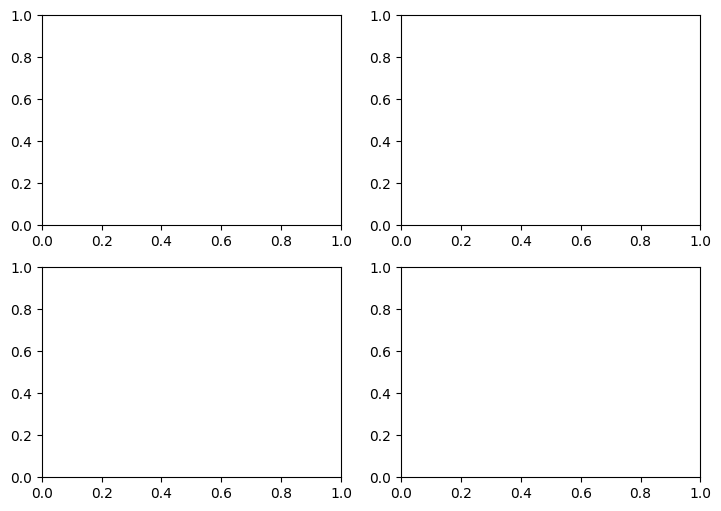

In [342]:
# new plot grids for next plots
# costs stats
fig_costs = plt.figure(figsize=(8.5, 6))
gs_costs = GridSpec(2, 2, figure=fig_costs, width_ratios=[1,1])
ax_left_top_costs = fig_costs.add_subplot(gs_costs[0, 0])
ax_left_bottom_costs = fig_costs.add_subplot(gs_costs[1, 0])
ax_right_top_costs = fig_costs.add_subplot(gs_costs[0, 1]) 
ax_right_bottom_costs = fig_costs.add_subplot(gs_costs[1, 1]) 

In [343]:
from statistics import median

# -- token usage line plots --
# y_values for token IN
agents_llm_calls_usage_gpt_mini = {a: [t.agent_usage_stats['llm_calls_count'] for t in agents_valid_trials_mini[a]] 
                                  for a in x_labels_agents}
agents_llm_calls_usage_gpt_nano = {a: [t.agent_usage_stats['llm_calls_count'] for t in agents_valid_trials_nano[a]] 
                                  for a in x_labels_agents}
                
# y_values for token OUT
agents_token_out_usage_gpt_mini = {a: [t.total_completion_tokens for t in agents_valid_trials_mini[a]] 
                                  for a in x_labels_agents}
agents_token_out_usage_gpt_nano = {a: [t.total_completion_tokens for t in agents_valid_trials_nano[a]] 
                                  for a in x_labels_agents}

# y_values for exec type

agents_time_gpt_mini = {a: [t.agent_system_exec_time_sec for t in agents_valid_trials_mini[a]] 
                                  for a in x_labels_agents}
agents_time_gpt_nano = {a: [t.agent_system_exec_time_sec for t in agents_valid_trials_nano[a]] 
                                  for a in x_labels_agents}

# plot
pprint({a: (len(ts), sum(ts), min(ts), max(ts), median(ts), iqr(ts)) for a, ts in agents_llm_calls_usage_gpt_mini.items()})
pprint({a: (len(ts), sum(ts), min(ts), max(ts), median(ts), iqr(ts)) for a, ts in agents_llm_calls_usage_gpt_nano.items()})
line_plot_with_box_plots(
    ax_left_top_costs, x_labels_agents, 
    y_values={'gpt-5-mini': agents_llm_calls_usage_gpt_mini, 'gpt-5-nano': agents_llm_calls_usage_gpt_nano}, 
    y_label='total LLM calls', y_lim=(0, 160), y_tic_steps=40, y_decimal_places=False
)
pprint({a: (len(ts), sum(ts), min(ts), max(ts), median(ts), iqr(ts)) for a, ts in agents_token_out_usage_gpt_mini.items()})
pprint({a: (len(ts), sum(ts), min(ts), max(ts), median(ts), iqr(ts)) for a, ts in agents_token_out_usage_gpt_nano.items()})
line_plot_with_box_plots(
    ax_right_top_costs, x_labels_agents, 
    y_values={'gpt-5-mini': agents_token_out_usage_gpt_mini, 'gpt-5-nano': agents_token_out_usage_gpt_nano}, 
    y_label='total compl. tokens', y_lim=(0, 180000), y_tic_steps=50000, y_decimal_places=False
)
pprint({a: (len(ts), sum(ts), min(ts), max(ts), median(ts), iqr(ts)) for a, ts in agents_time_gpt_mini.items()})
pprint({a: (len(ts), sum(ts), min(ts), max(ts), median(ts), iqr(ts)) for a, ts in agents_time_gpt_nano.items()})
line_plot_with_box_plots(
    ax_left_bottom_costs, x_labels_agents, 
    y_values={'gpt-5-mini': agents_time_gpt_mini, 'gpt-5-nano': agents_time_gpt_nano}, 
    y_label='exec time in s', y_lim=(0, 2300), y_tic_steps=500, y_decimal_places=False
)

{'singleton': (244, 5818, 1, 100, 16.5, np.float64(23.0)),
 'spoox-l': (95, 4409, 16, 150, 44, np.float64(23.0)),
 'spoox-m': (264, 10101, 12, 133, 31.0, np.float64(24.0)),
 'spoox-s': (177, 6312, 6, 133, 27, np.float64(28.0))}
{'singleton': (217, 4218, 1, 100, 13, np.float64(20.0)),
 'spoox-l': (88, 3480, 8, 105, 32.5, np.float64(33.25)),
 'spoox-m': (165, 5718, 7, 133, 25, np.float64(35.0)),
 'spoox-s': (182, 4794, 3, 100, 20.0, np.float64(24.75))}


<Figure size 640x480 with 0 Axes>

{'singleton': (244, 3833518, 2307, 72733, 10156.5, np.float64(12732.5)),
 'spoox-l': (95, 2991998, 6773, 98225, 27470, np.float64(16165.5)),
 'spoox-m': (264, 6457694, 4605, 113187, 20557.0, np.float64(13110.75)),
 'spoox-s': (177, 3656686, 2927, 89492, 15066, np.float64(15382.0))}
{'singleton': (217, 5615065, 3613, 145127, 17958, np.float64(22646.0)),
 'spoox-l': (88, 5770674, 11691, 166051, 57579.5, np.float64(54089.75)),
 'spoox-m': (165, 8682804, 8145, 155974, 43740, np.float64(42909.0)),
 'spoox-s': (182, 7763798, 6637, 172514, 30717.5, np.float64(33380.75))}


<Figure size 640x480 with 0 Axes>

{'singleton': (244,
               82089.11434817314,
               30.03810739517212,
               1766.6936893463135,
               210.0643241405487,
               np.float64(326.93020313978195)),
 'spoox-l': (95,
             58745.42429757118,
             140.5195074081421,
             1938.431491136551,
             544.425342798233,
             np.float64(266.812805891037)),
 'spoox-m': (264,
             127464.17088389397,
             98.59667730331421,
             2138.442989587784,
             385.3515672683716,
             np.float64(302.13184720277786)),
 'spoox-s': (177,
             78523.04759764671,
             60.30691981315613,
             1724.25004529953,
             339.0313060283661,
             np.float64(409.332656621933))}
{'singleton': (217,
               64209.930015563965,
               34.03997087478638,
               1560.3898632526398,
               213.18650889396667,
               np.float64(268.7120683193207)),
 'spoox-l': (88,
  

<Figure size 640x480 with 0 Axes>

In [344]:
# all happened exception types
all_exception_types = set()
for tb_run in tb_runs:
    for trial in tb_run.trials.values():
        if trial.exception_type is not None:
            all_exception_types.add(trial.exception_type)
all_exception_types

{'AgentTimeoutError'}

In [345]:
# -- execution-time line plot --
# gather data
y_values_timeout_errors = {m: [[] for _ in x_labels_agents] for m in models}
for m in models:
    for i, x in enumerate(x_labels_agents):
        for r in tb_runs:
            if r.model == m and r.agent == x:
                agent_timeout_errors = 0
                for t in r.trials.values():
                    if t.total_prompt_tokens is None or t.total_completion_tokens is None or t.agent_system_exec_time_sec is None:
                        continue
                    if t.total_prompt_tokens <= 0 or t.total_completion_tokens <= 0:
                        continue
                    if t.exception_type != "AgentTimeoutError":
                        continue
                    agent_timeout_errors += 1
                y_values_timeout_errors[m][i].append(agent_timeout_errors)

print(y_values_timeout_errors)
print([mean(vs) for vs in y_values_timeout_errors['gpt-5-mini']])
print([mean(vs) for vs in y_values_timeout_errors['gpt-5-nano']])
line_plot(
    ax_right_bottom_costs, x_labels_agents,
    y_1_values = y_values_timeout_errors, y_1_label = 'timeouts',
    y_1_lim = (0, 60), y_1_tic_steps = 10, y_1_decimal_places=False, additional_boxes=True, close_legend=False
)

{'gpt-5-mini': [[4, 3, 3], [21, 26, 19], [29, 23, 34, 30, 32], [50, 52, 48]], 'gpt-5-nano': [[2, 0, 1], [24, 21, 27], [24, 32, 21], [43, 22, 48]]}
[3.3333333333333335, 22, 29.6, 50]
[1, 24, 25.666666666666668, 37.666666666666664]


In [346]:
# save plots
fig_costs.tight_layout()
fig_costs.savefig("figure_costs.pdf")

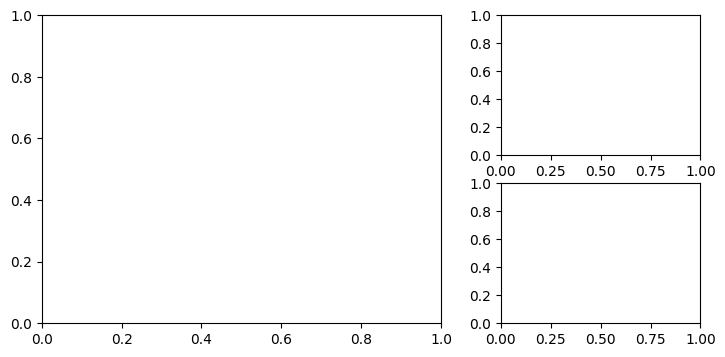

In [347]:
# new plot grids for next plots
# costs stats
fig_tools = plt.figure(figsize=(8.5, 4))
gs_tools = GridSpec(2, 2, figure=fig_tools, width_ratios=[2,1])
ax_left_tools = fig_tools.add_subplot(gs_tools[:, 0])
ax_right_top_tools = fig_tools.add_subplot(gs_tools[0, 1]) 
ax_right_bottom_tools = fig_tools.add_subplot(gs_tools[1, 1]) 

In [348]:
list(tb_runs[1].trials.values())[0].agent_usage_stats['next_agent_calling_chain']

['subtaskplanner',
 'subtasksolver',
 'subtaskplanner',
 'tester',
 'refiner',
 'approver',
 'summarizer']

In [349]:
# tool call stats - box plots
y_values_tool_usages = []
# collect data
all_tool_names = set()
for m in models:
    for a in x_labels_agents:
        tool_usage = {
            'model': m,
            'agent': a,
            'Shell': 0,
            'Terminal': 0,
            'duckduckgo_results_json': 0,  # search tool
            'CodeExecutor': 0,  # python tool
        }
        for r in tb_runs:
            if r.model != m or r.agent != a:
                continue
            for t in r.trials.values():
                if t.agent_usage_stats is not None:
                    for tc_name, tc_count in t.agent_usage_stats['tool_call_counts'].items():
                        tool_usage[tc_name] += tc_count
                        all_tool_names.add(tc_name)
        # manuel renamings
        y_values_tool_usages.append(tool_usage)
        
# calc percentage
for tu in y_values_tool_usages:
    total = sum(c for c in tu.values() if type(c) is int)
    tu['shell'] = tu['Shell'] / total if total > 0 else None
    del tu['Shell']
    tu['terminal'] = tu['Terminal'] / total if total > 0 else None
    del tu['Terminal']
    tu['search'] = tu['duckduckgo_results_json'] / total if total > 0 else None
    del tu['duckduckgo_results_json']
    tu['python'] = tu['CodeExecutor'] / total if total > 0 else None
    del tu['CodeExecutor']

print(all_tool_names)
ax_left_tools.set_title('Average tool usage', fontsize=10)
plot_model_agent_heatmap(ax_left_tools, y_values_tool_usages)

{'duckduckgo_results_json', 'CodeExecutor', 'Shell', 'Terminal'}


/Users/linus/Documents/TUM/MA/code/agentu/benchmarks/harbor/analytics/plot_utilities.py:640: UserWarning: Adding colorbar to a different Figure <Figure size 850x400 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax)


<Figure size 640x480 with 0 Axes>

In [350]:
# tool calls check
tool_calls_count = 0
tool_calls_failures = 0
t_model = 'gpt-5-nano'   # todo model!
for r in tb_runs:
    if r.model != t_model:
        continue
    for t in r.trials.values():
        if t.agent_usage_stats is None:
            continue
        for call, result in t.agent_usage_stats['tool_calls']:  
            tool_calls_count += 1
            if result.is_error:
                tool_calls_failures += 1
print(f"{tool_calls_count} tool calls ({tool_calls_failures} failed)")

30171 tool calls (79 failed)


In [351]:
# shell tool calls error codes
tool_calls_count = 0
shell_tool_exit_codes = list()

ec_model = 'gpt-5-mini'  

# go through every tool call ever happened
for r in tb_runs:
    if r.model != ec_model:
        continue
    for t in r.trials.values():
        if t.agent_usage_stats is None:
            continue
        for call, result in t.agent_usage_stats['tool_calls']:  
            tool_calls_count += 1
            if result.is_error or result.name != 'Shell':
                continue
            # extract return code
            tool_return_content = result.content
            start = tool_return_content.find("<exit-code>") + len("<exit-code>")
            end = tool_return_content.find("</exit-code>")
            shell_tool_exit_codes.append(int(tool_return_content[start:end].strip()))
              
# show results  
print(f"{tool_calls_count} tool calls")
print(f"{len(shell_tool_exit_codes)} collected shell tool exit codes ({shell_tool_exit_codes.count(0)} are 0s)")
print(f"{len(set(shell_tool_exit_codes))} collected unique shell tool exit codes")
for ec in [1, 2, 127]:  # most common error codes are: 1, 2, 127
    print(f"error code {ec}: {shell_tool_exit_codes.count(ec)}")
    
# plot
ec_others_count = len(shell_tool_exit_codes) - shell_tool_exit_codes.count(0) - shell_tool_exit_codes.count(1) - shell_tool_exit_codes.count(2) - shell_tool_exit_codes.count(127)
ec_data = {
    'no errors': shell_tool_exit_codes.count(0),
    'errors': {
        '1': shell_tool_exit_codes.count(1), 
        '2': shell_tool_exit_codes.count(2), 
        '127': shell_tool_exit_codes.count(127), 
        'others': ec_others_count
    },
}
ax_right_top_tools.set_title(f'Shell exit codes – {ec_model}', fontsize=10)
label_colors = {'no errors': Color.GREEN, '1': Color.YELLOW, '2': Color.LIGHT_ORANGE, '127': Color.PURPLE, 'others': Color.DARK_GREY}
plot_error_code_bars(ax_right_top_tools, ec_data, label_colors)

55684 tool calls
37835 collected shell tool exit codes (33173 are 0s)
25 collected unique shell tool exit codes
error code 1: 2609
error code 2: 501
error code 127: 1228


In [352]:
# shell tool calls error codes
tool_calls_count = 0
shell_tool_exit_codes = list()

ec_model = 'gpt-5-nano'  

# go through every tool call ever happened
for r in tb_runs:
    if r.model != ec_model:
        continue
    for t in r.trials.values():
        if t.agent_usage_stats is None:
            continue
        for call, result in t.agent_usage_stats['tool_calls']:  
            tool_calls_count += 1
            if result.is_error or result.name != 'Shell':
                continue
            # extract return code
            tool_return_content = result.content
            start = tool_return_content.find("<exit-code>") + len("<exit-code>")
            end = tool_return_content.find("</exit-code>")
            shell_tool_exit_codes.append(int(tool_return_content[start:end].strip()))
              
# show results  
print(f"{tool_calls_count} tool calls")
print(f"{len(shell_tool_exit_codes)} collected shell tool exit codes ({shell_tool_exit_codes.count(0)} are 0s)")
print(f"{len(set(shell_tool_exit_codes))} collected unique shell tool exit codes")
for ec in [1, 2, 127]:  # most common error codes are: 1, 2, 127
    print(f"error code {ec}: {shell_tool_exit_codes.count(ec)}")

# plot
ec_others_count = len(shell_tool_exit_codes) - shell_tool_exit_codes.count(0) - shell_tool_exit_codes.count(1) - shell_tool_exit_codes.count(2) - shell_tool_exit_codes.count(127)
ec_data = {
    'no errors': shell_tool_exit_codes.count(0),
    'errors': {
        '1': shell_tool_exit_codes.count(1), 
        '2': shell_tool_exit_codes.count(2), 
        '127': shell_tool_exit_codes.count(127), 
        'others': ec_others_count
    },
}
ax_right_bottom_tools.set_title(f'Shell exit codes – {ec_model}', fontsize=10)
label_colors = {'no errors': Color.GREEN, '1': Color.YELLOW, '2': Color.LIGHT_ORANGE, '127': Color.PURPLE, 'others': Color.DARK_GREY}
plot_error_code_bars(ax_right_bottom_tools, ec_data, label_colors, show_legend=False)

30171 tool calls
26361 collected shell tool exit codes (18848 are 0s)
26 collected unique shell tool exit codes
error code 1: 2449
error code 2: 3780
error code 127: 965


In [353]:
# save plots
fig_tools.tight_layout()
fig_tools.savefig("figure_tools.pdf")

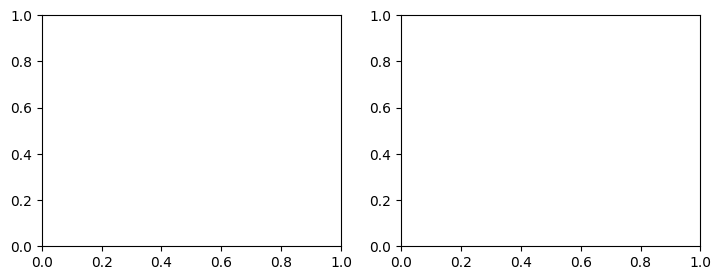

In [354]:
# new plot grids for next plots
# costs stats
fig_gc = plt.figure(figsize=(8.5, 3))
gs_gc = GridSpec(1, 2, figure=fig_gc, width_ratios=[1,1])
ax_left_gc = fig_gc.add_subplot(gs_gc[:, 0])
ax_right_gc = fig_gc.add_subplot(gs_gc[:, 1])

In [355]:
# group chat message lengths - line plots
agents_mas = ['spoox-s', 'spoox-m', 'spoox-l']

# collect data
agents_gc_growth_gpt_mini = {a: [] for a in agents_mas}  
for a in agents_gc_growth_gpt_mini.keys():
    for t in agents_valid_trials_mini[a]:
        if t.agent_usage_stats is None:
            continue
        gc_message_lengths = t.agent_usage_stats['group_chat_message_lengths']
        acc_gc_lengths = [0]
        for i, l in enumerate(gc_message_lengths):  # accumulate message lengths
            acc_gc_lengths.append(acc_gc_lengths[i] + l)
        agents_gc_growth_gpt_mini[a].append(acc_gc_lengths)        
    
agents_gc_growth_gpt_nano = {a: [] for a in agents_mas} 
for a in agents_gc_growth_gpt_nano.keys():
    for t in agents_valid_trials_nano[a]:
        if t.agent_usage_stats is None:
            continue
        gc_message_lengths = t.agent_usage_stats['group_chat_message_lengths']
        acc_gc_lengths = [0]
        for i, l in enumerate(gc_message_lengths):  # accumulate message lengths
            acc_gc_lengths.append(acc_gc_lengths[i] + l)
        agents_gc_growth_gpt_nano[a].append(acc_gc_lengths)

# plot data
ax_left_gc.set_title(f'gpt-5-mini', fontsize=10)
plot_model_series(ax_left_gc, agents_gc_growth_gpt_mini, 70000, 20)
ax_right_gc.set_title(f'gpt-5-nano', fontsize=10)
plot_model_series(ax_right_gc, agents_gc_growth_gpt_nano, 70000, 20)

In [356]:
# save plots
fig_gc.tight_layout()
fig_gc.savefig("figure_gc.pdf")

Text(0.02, 0.3, 'gpt-5-nano')

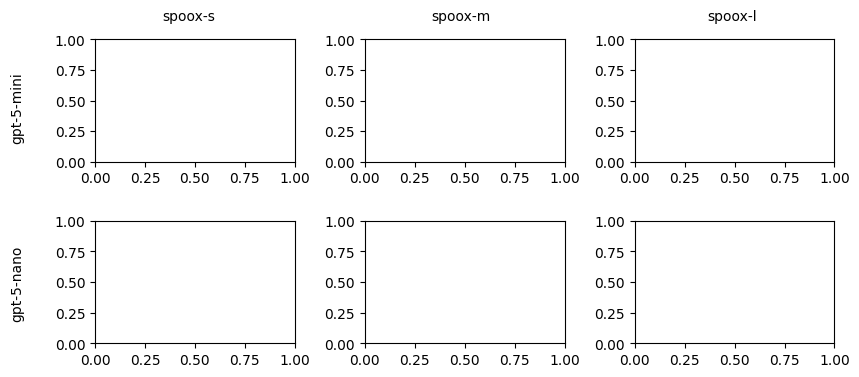

In [357]:
# new plot grids for next plots
# costs stats
fig_a = plt.figure(figsize=(8.5, 4))
gs_a = GridSpec(2, 3, figure=fig_a, width_ratios=[1,1,1], wspace=0.35, hspace=0.48 ,left=0.12,
    right=0.99,
    top=0.91,
    bottom=0.15)
ax_left_1_a = fig_a.add_subplot(gs_a[0, 0])
ax_left_2_a = fig_a.add_subplot(gs_a[1, 0])
ax_middle_1_a = fig_a.add_subplot(gs_a[0, 1])
ax_middle_2_a = fig_a.add_subplot(gs_a[1, 1])
ax_right_1_a = fig_a.add_subplot(gs_a[0, 2])
ax_right_2_a = fig_a.add_subplot(gs_a[1, 2])

# special: titles
fig_a.text(0.23, 0.95, "spoox-s",   ha="center", va="bottom", fontsize=10)
fig_a.text(0.55, 0.95, "spoox-m", ha="center", va="bottom", fontsize=10)
fig_a.text(0.87, 0.95, "spoox-l",  ha="center", va="bottom", fontsize=10)
fig_a.text(0.02, 0.74, "gpt-5-mini",    ha="left", va="center", fontsize=10, rotation=90)
fig_a.text(0.02, 0.30, "gpt-5-nano", ha="left", va="center", fontsize=10, rotation=90)

In [358]:
# agent execution plots
agent_loops = {
    'spoox-s': ['T ▸ S'],
    'spoox-m': ['T ▸ S', 'A ▸ S', 'A ▸ T'],
    'spoox-l': ['STP ▸ E', 'STS ▸ STP', 'R ▸ T', 'A ▸ T', 'A ▸ R'],
}
all_single_agents = ['explorer', 'solver', 'subtaskplanner', 'subtasksolver', 'tester', 'refiner', 'approver', 'summarizer']
label_pairings_mapping = {
    'T ▸ S': ('tester', 'solver'),
    'A ▸ S': ('approver', 'solver'),
    'A ▸ T': ('approver', 'tester'),
    'STP ▸ E': ('subtaskplanner', 'explorer'),
    'STS ▸ STP': ('subtasksolver', 'subtaskplanner'),
    'R ▸ T': ('refiner', 'tester'),
    'A ▸ R': ('approver', 'refiner'),
}

# collect data
def collect_loop(m: str, a: str, log: bool = True):
    loops = {l: 0 for l in ['no loop'] + agent_loops[a]} 
    ts = agents_valid_trials_mini[a] if m == 'gpt-5-mini' else agents_valid_trials_nano[a]
    invalid_chains = []
    total_chains = 0
    
    for t in ts:
        if t.agent_usage_stats is None:
            continue
        agent_chain = t.agent_usage_stats['next_agent_calling_chain']
        total_chains += 1
        if len(agent_chain) <= 1:
            invalid_chains.append(agent_chain)
            continue
        # attention: bug in logs -> last entry includes first agent again cause the start of next cycle is recorded (eg explorer for m) -> however, no influence on our loop analysis
        # attention: bug in logs -> first called agent is never recorded -> however, no influence on our loop analysis
        
        # extract loops
        pairs = list(zip(agent_chain, agent_chain[1:]))
        # count loops
        loops_sum = 0
        for l in agent_loops[a]: 
            l_pair = label_pairings_mapping[l]
            l_count = pairs.count(l_pair)
            loops[l] += l_count
            loops_sum += l_count
        if loops_sum == 0:
            loops['no loop'] += 1
    if log:
        print(f"-> analysed loops for {m} – {a}")
        print(f"invalid chains: {len(invalid_chains)}")
        print(f"total chains: {total_chains}")
        pprint(loops)
    return loops, total_chains - len(invalid_chains)

In [359]:
collect_loop('gpt-5-mini', 'spoox-s')
collect_loop('gpt-5-mini', 'spoox-m')
_ = collect_loop('gpt-5-mini', 'spoox-l')


-> analysed loops for gpt-5-mini – spoox-s
invalid chains: 10
total chains: 177
{'T ▸ S': 98, 'no loop': 120}
-> analysed loops for gpt-5-mini – spoox-m
invalid chains: 7
total chains: 264
{'A ▸ S': 4, 'A ▸ T': 15, 'T ▸ S': 125, 'no loop': 180}
-> analysed loops for gpt-5-mini – spoox-l
invalid chains: 0
total chains: 95
{'A ▸ R': 2,
 'A ▸ T': 2,
 'R ▸ T': 17,
 'STP ▸ E': 4,
 'STS ▸ STP': 255,
 'no loop': 2}


In [360]:
collect_loop('gpt-5-nano', 'spoox-s')
collect_loop('gpt-5-nano', 'spoox-m')
_ = collect_loop('gpt-5-nano', 'spoox-l')

-> analysed loops for gpt-5-nano – spoox-s
invalid chains: 2
total chains: 182
{'T ▸ S': 371, 'no loop': 92}
-> analysed loops for gpt-5-nano – spoox-m
invalid chains: 1
total chains: 165
{'A ▸ S': 5, 'A ▸ T': 9, 'T ▸ S': 376, 'no loop': 74}
-> analysed loops for gpt-5-nano – spoox-l
invalid chains: 0
total chains: 88
{'A ▸ R': 1,
 'A ▸ T': 0,
 'R ▸ T': 20,
 'STP ▸ E': 32,
 'STS ▸ STP': 273,
 'no loop': 1}


In [361]:
plot_count_bars(ax_left_1_a, *collect_loop('gpt-5-mini', 'spoox-s', log=False), Color.DARK_BLUE)
plot_count_bars(ax_middle_1_a, *collect_loop('gpt-5-mini', 'spoox-m', log=False), Color.DARK_BLUE)
plot_count_bars(ax_right_1_a, *collect_loop('gpt-5-mini', 'spoox-l', log=False), Color.DARK_BLUE)
plot_count_bars(ax_left_2_a, *collect_loop('gpt-5-nano', 'spoox-s', log=False), Color.ORANGE, total_label_right=False)
plot_count_bars(ax_middle_2_a, *collect_loop('gpt-5-nano', 'spoox-m', log=False), Color.ORANGE)
plot_count_bars(ax_right_2_a, *collect_loop('gpt-5-nano', 'spoox-l', log=False), Color.ORANGE)

In [362]:
# save plots
fig_a.tight_layout()
fig_a.savefig("figure_loops.pdf")

/var/folders/28/k4fp3yls1jl_ntlms33nvg4r0000gn/T/ipykernel_75954/4240099154.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_a.tight_layout()
